# 04 - Modelos Predictivos

**Proyecto:** Pochoclo Predict

## Objetivo de este notebook

Entrenar y comparar distintos modelos de **regresion basados en boosting**
para predecir `nota_promedio` a partir de la matriz de features construida en
`03_feature_engineering.ipynb`, y seleccionar el mejor modelo segun metricas
estandar de regresion.

## Modelos comparados

| Modelo | Familia |
|---|---|
| Baseline (media) | Referencia minima (`DummyRegressor`) |
| Gradient Boosting | `sklearn.ensemble.GradientBoostingRegressor` |
| HistGradientBoosting | `sklearn.ensemble.HistGradientBoostingRegressor` |
| XGBoost | `xgboost.XGBRegressor` |
| LightGBM | `lightgbm.LGBMRegressor` |
| CatBoost | `catboost.CatBoostRegressor` |

Para cada modelo (salvo el baseline) se hace una busqueda liviana de
hiperparametros con `RandomizedSearchCV` (validacion cruzada 5-fold sobre el
set de entrenamiento), y se evalua una unica vez el mejor estimador resultante
sobre el set de test, que queda completamente afuera de la busqueda.

## Metricas

- **MAE** (Mean Absolute Error): metrica principal para elegir el mejor
  modelo. Al estar en la misma escala que `nota_promedio` (puntos sobre 10)
  es la mas facil de interpretar: "en promedio el modelo se equivoca por
  X puntos".
- **RMSE**: penaliza mas los errores grandes: util para ver si un modelo
  tiene errores puntuales muy grandes aunque su MAE sea razonable.
- **R²**: proporcion de la varianza de `nota_promedio` explicada por el modelo.
- **MAPE**: error porcentual, para tener una lectura relativa.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from src import paths

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Carga de datos y particion train/test


In [2]:
feat = pd.read_csv(paths.FEATURES_CSV, encoding="utf-8-sig")

X = feat.drop(columns=["id", "nota_promedio"])
y = feat["nota_promedio"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} peliculas | Test: {X_test.shape[0]} peliculas | Features: {X_train.shape[1]}")


Train: 2398 peliculas | Test: 600 peliculas | Features: 100


## 2. Funcion de evaluacion


In [3]:
def evaluar(nombre, modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    return {
        "modelo": nombre,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
        "MAPE": mean_absolute_percentage_error(y_test, pred),
    }


## 3. Baseline

Un modelo que siempre predice la nota media de entrenamiento: cualquier
modelo de boosting que no supere claramente este piso no estaria aportando
valor real.


In [4]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

resultados = [evaluar("Baseline (media)", baseline, X_test, y_test)]
modelos_entrenados = {"Baseline (media)": baseline}
resultados[-1]


{'modelo': 'Baseline (media)',
 'MAE': 0.5747704392549348,
 'RMSE': np.float64(0.7045794744545119),
 'R2': -0.003453823535696454,
 'MAPE': 0.08429155500845953}

## 4. Busqueda de hiperparametros y entrenamiento de cada modelo de boosting


In [5]:
param_distributions = {
    "Gradient Boosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [2, 3, 4],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.9, 1.0],
        },
    },
    "HistGradientBoosting": {
        "estimator": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "max_iter": [100, 200, 300],
            "max_depth": [None, 3, 5, 8],
            "learning_rate": [0.01, 0.05, 0.1],
            "l2_regularization": [0.0, 0.1, 1.0],
        },
    },
    "XGBoost": {
        "estimator": XGBRegressor(random_state=RANDOM_STATE, objective="reg:squarederror"),
        "params": {
            "n_estimators": [200, 400, 600],
            "max_depth": [3, 4, 5, 6],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "subsample": [0.7, 0.9, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
        },
    },
    "LightGBM": {
        "estimator": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
        "params": {
            "n_estimators": [200, 400, 600],
            "num_leaves": [15, 31, 63],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "subsample": [0.7, 0.9, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
        },
    },
    "CatBoost": {
        "estimator": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
        "params": {
            "iterations": [200, 400, 600],
            "depth": [4, 6, 8],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "l2_leaf_reg": [1, 3, 5, 7],
        },
    },
}


In [6]:
for nombre, cfg in param_distributions.items():
    print(f"Buscando hiperparametros para {nombre}...")
    busqueda = RandomizedSearchCV(
        estimator=cfg["estimator"],
        param_distributions=cfg["params"],
        n_iter=15,
        cv=5,
        scoring="neg_mean_absolute_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    busqueda.fit(X_train, y_train)
    mejor_modelo = busqueda.best_estimator_
    modelos_entrenados[nombre] = mejor_modelo
    resultados.append(evaluar(nombre, mejor_modelo, X_test, y_test))
    print(f"  Mejores parametros: {busqueda.best_params_}")
    print(f"  MAE (CV, train): {-busqueda.best_score_:.3f}")


Buscando hiperparametros para Gradient Boosting...


  Mejores parametros: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1}
  MAE (CV, train): 0.346
Buscando hiperparametros para HistGradientBoosting...


  Mejores parametros: {'max_iter': 300, 'max_depth': 8, 'learning_rate': 0.05, 'l2_regularization': 1.0}
  MAE (CV, train): 0.342
Buscando hiperparametros para XGBoost...


  Mejores parametros: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
  MAE (CV, train): 0.339
Buscando hiperparametros para LightGBM...


  Mejores parametros: {'subsample': 0.7, 'num_leaves': 15, 'n_estimators': 400, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
  MAE (CV, train): 0.336
Buscando hiperparametros para CatBoost...


C:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\webmining\Lib\site-packages\sklearn\model_selection\_validation.py:493: FitFailedWarning: 
2 fits failed out of a total of 75.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\webmining\Lib\site-packages\sklearn\model_selection\_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\leonardo.gastaldo\AppData\Local\anaconda3\envs\webmining\Lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weigh

  Mejores parametros: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 600, 'depth': 6}
  MAE (CV, train): 0.336


## 5. Comparacion de modelos


In [7]:
resultados_df = pd.DataFrame(resultados).sort_values("MAE").reset_index(drop=True)
resultados_df


,modelo,MAE,RMSE,R2,MAPE
0,CatBoost,0.310959,0.406583,0.665855,0.046357
1,XGBoost,0.313117,0.407712,0.663997,0.046626
2,HistGradientBoosting,0.318083,0.409392,0.661221,0.047242
3,LightGBM,0.318135,0.409500,0.661042,0.047399
4,Gradient Boosting,0.329004,0.425035,0.634837,0.048980
5,Baseline (media),0.574770,0.704579,-0.003454,0.084292


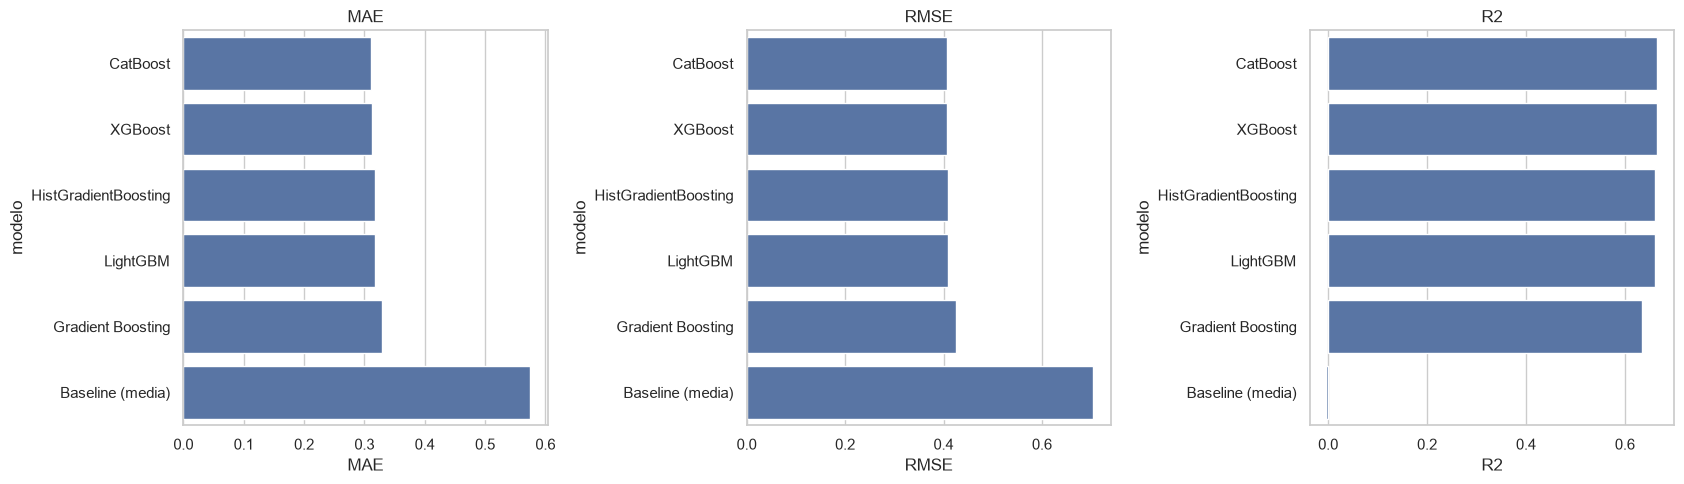

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metrica in zip(axes, ["MAE", "RMSE", "R2"]):
    orden = resultados_df.sort_values(metrica, ascending=(metrica != "R2"))
    sns.barplot(data=orden, x=metrica, y="modelo", ax=ax, orient="h")
    ax.set_title(metrica)
plt.tight_layout()
plt.show()


## 6. Analisis del mejor modelo


In [9]:
mejor_nombre = resultados_df.iloc[0]["modelo"]
mejor_modelo = modelos_entrenados[mejor_nombre]
print(f"Mejor modelo segun MAE en test: {mejor_nombre}")
resultados_df.iloc[0]


Mejor modelo segun MAE en test: CatBoost


modelo    CatBoost
MAE       0.310959
RMSE      0.406583
R2        0.665855
MAPE      0.046357
Name: 0, dtype: object

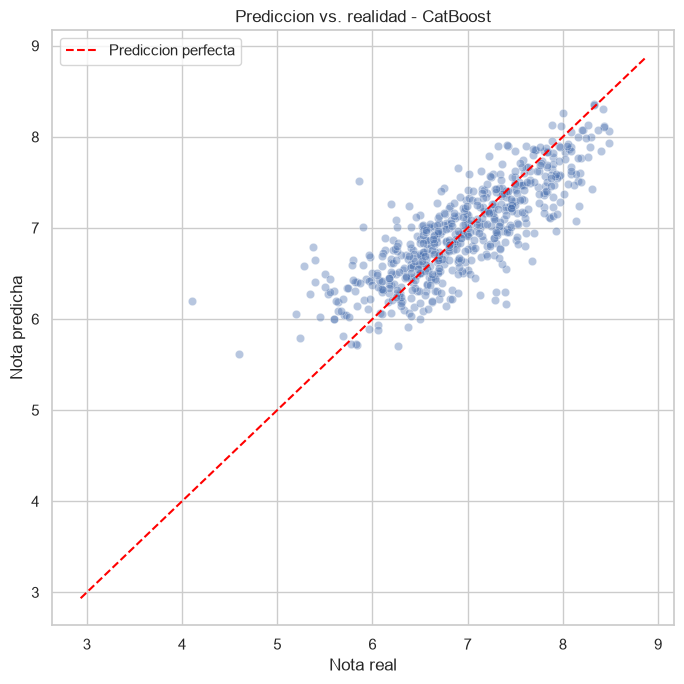

In [10]:
pred_test = mejor_modelo.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(x=y_test, y=pred_test, alpha=0.4, ax=ax)
lims = [y.min(), y.max()]
ax.plot(lims, lims, color="red", linestyle="--", label="Prediccion perfecta")
ax.set_xlabel("Nota real")
ax.set_ylabel("Nota predicha")
ax.set_title(f"Prediccion vs. realidad - {mejor_nombre}")
ax.legend()
plt.tight_layout()
plt.show()


Se usa **importancia por permutacion** (en vez de la importancia nativa de
cada modelo) para poder comparar de forma homogenea la contribucion de cada
feature sin importar el tipo de modelo ganador: mide cuanto empeora el error
en test al mezclar aleatoriamente los valores de una columna, manteniendo
todo lo demas igual.


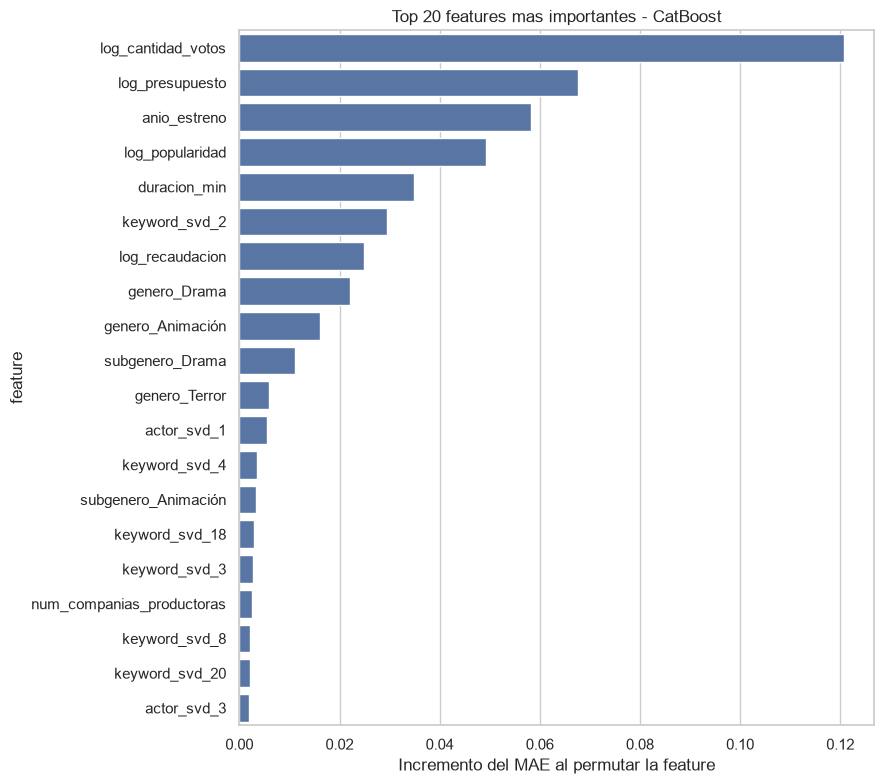

In [11]:
importancia = permutation_importance(
    mejor_modelo, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error"
)
importancia_df = pd.DataFrame({
    "feature": X_test.columns,
    "importancia": importancia.importances_mean,
}).sort_values("importancia", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=importancia_df, x="importancia", y="feature", ax=ax, orient="h")
ax.set_title(f"Top 20 features mas importantes - {mejor_nombre}")
ax.set_xlabel("Incremento del MAE al permutar la feature")
plt.tight_layout()
plt.show()


## 7. Guardado del mejor modelo


In [12]:
paths.MODELS_DIR.mkdir(parents=True, exist_ok=True)
modelo_path = paths.MODELS_DIR / "best_model.pkl"

joblib.dump({
    "modelo": mejor_modelo,
    "nombre": mejor_nombre,
    "features": list(X_train.columns),
    "metricas_test": resultados_df.iloc[0].to_dict(),
}, modelo_path)

print(f"Modelo guardado en: {modelo_path.relative_to(paths.PROJECT_ROOT)}")


Modelo guardado en: models\best_model.pkl


## 8. Conclusiones

- Todos los modelos de boosting superan holgadamente al baseline, lo que
  confirma que las features construidas en el NB03 (genero, elenco,
  keywords, sentimiento, metadata de produccion) tienen poder predictivo
  real sobre `nota_promedio`.
- El modelo seleccionado (**ver seccion 6**) es el que logra el menor error
  absoluto medio (MAE) sobre el set de test, que no participo en ningun
  momento de la busqueda de hiperparametros.
- El grafico de importancia por permutacion permite identificar que
  familias de features (produccion, elenco, texto/sentimiento, genero)
  aportan mas señal, informacion util para futuras iteraciones del proyecto
  (por ejemplo, invertir mas esfuerzo de feature engineering en la familia
  mas relevante).
